In [1]:
import logging
from nlab_modbus.manager import DeviceManager
import time
import matplotlib.pyplot as plt


logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(name)s | %(message)s",
    force=True
)
logging.getLogger("pymodbus").setLevel(logging.CRITICAL)
logging.getLogger("pymodbus.logging").setLevel(logging.CRITICAL)


In [2]:
mgr = DeviceManager()

In [3]:
ips = await mgr.scan_remote_ips_async()
print(ips)

['192.168.10.134', '192.168.10.128']


In [4]:
mgr.scan_local_ports()

2026-05-28 15:01:03,806 | INFO     | nlab_modbus.discovery.scan | Register found: 257


In [5]:
mgr.local

In [6]:
mgr.local[0].connection_info()

'serial://COM6:1'

In [7]:
mgr.local[0].get_board_temp()

27.67

In [8]:
for ip in ips:
    mgr.scan_remote(ip, [5001, 5002])

2026-05-28 15:01:11,555 | INFO     | nlab_modbus.discovery.scan | Register found: 769


2026-05-28 15:01:13,490 | INFO     | nlab_modbus.discovery.scan | Register found: 257
2026-05-28 15:01:13,528 | INFO     | nlab_modbus.discovery.scan | Register found: 513


In [9]:
mgr.remote

In [10]:
mgr.remote[0].set_pwm_enable(1)

In [11]:
mgr.all_devices

In [12]:
mgr.close_all()

In [13]:
mgr.local[0].connect()

In [20]:
temps = []
counts = []
times = []
t0 = time.monotonic()
dt = 0.25
next_time = t0 + dt  # Absolute target for first
for i in range(200):
    t_loop_0 = time.time()
    temp = mgr.local[0].get_board_temp()
    cps = mgr.remote[2].get_pulses_per_sec()
    temps.append(temp)
    counts.append(cps)
    times.append(time.monotonic() - t0)
    print(f"{times[-1]:8.2f} s, {temp:7.2f} °C, {cps:6d} cps", end="\r")
    t_loop = time.time() - t_loop_0
    next_time += dt
    sleep_dur = next_time - time.monotonic()
    if sleep_dur > 0:
        time.sleep(sleep_dur)

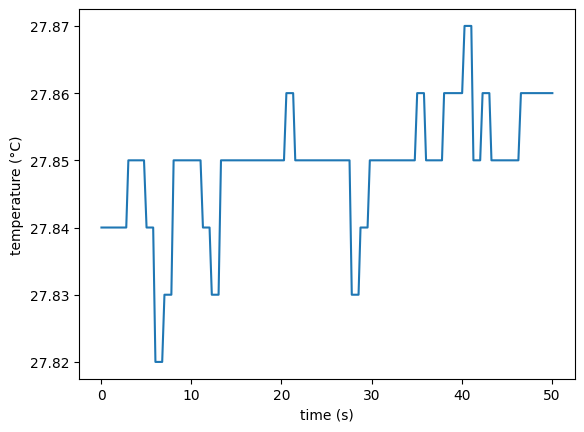

In [21]:
plt.figure()
plt.plot(times, temps)
plt.xlabel('time (s)')
plt.ylabel('temperature (°C)')
plt.show()

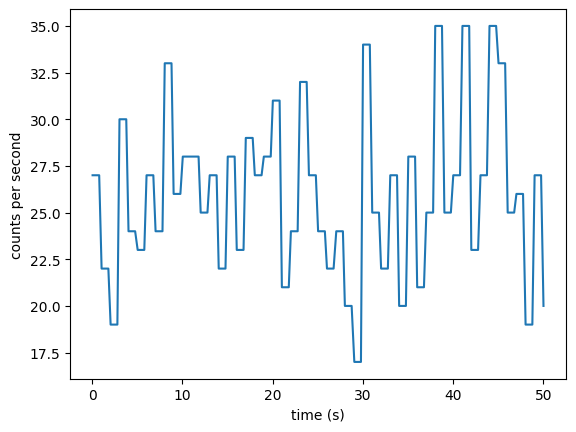

In [22]:
plt.figure()
plt.plot(times, counts)
plt.xlabel('time (s)')
plt.ylabel('counts per second')
plt.show()

In [23]:
import numpy as np

In [24]:
np.array(times[1:]) - np.array(times[:-1])

array([0.468, 0.266, 0.266, 0.25 , 0.218, 0.282, 0.25 , 0.234, 0.25 ,
       0.266, 0.234, 0.266, 0.234, 0.25 , 0.25 , 0.266, 0.25 , 0.218,
       0.282, 0.25 , 0.234, 0.25 , 0.25 , 0.266, 0.25 , 0.234, 0.25 ,
       0.25 , 0.25 , 0.266, 0.25 , 0.234, 0.25 , 0.266, 0.234, 0.25 ,
       0.266, 0.234, 0.266, 0.234, 0.266, 0.234, 0.25 , 0.266, 0.234,
       0.266, 0.234, 0.25 , 0.266, 0.234, 0.25 , 0.266, 0.234, 0.266,
       0.234, 0.25 , 0.266, 0.234, 0.25 , 0.266, 0.234, 0.266, 0.234,
       0.25 , 0.266, 0.234, 0.25 , 0.266, 0.234, 0.266, 0.234, 0.25 ,
       0.266, 0.234, 0.25 , 0.266, 0.234, 0.266, 0.234, 0.25 , 0.266,
       0.234, 0.25 , 0.266, 0.234, 0.266, 0.234, 0.25 , 0.266, 0.234,
       0.266, 0.218, 0.282, 0.234, 0.25 , 0.266, 0.234, 0.266, 0.25 ,
       0.218, 0.282, 0.25 , 0.234, 0.25 , 0.266, 0.218, 0.297, 0.203,
       0.282, 0.25 , 0.218, 0.282, 0.25 , 0.218, 0.297, 0.203, 0.282,
       0.25 , 0.234, 0.25 , 0.266, 0.234, 0.266, 0.234, 0.25 , 0.266,
       0.234, 0.266,

(array([ 4., 12., 55.,  0., 53., 59.,  0., 12.,  3.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([0.203     , 0.21404167, 0.22508333, 0.236125  , 0.24716667,
        0.25820833, 0.26925   , 0.28029167, 0.29133333, 0.302375  ,
        0.31341667, 0.32445833, 0.3355    , 0.34654167, 0.35758333,
        0.368625  , 0.37966667, 0.39070833, 0.40175   , 0.41279167,
        0.42383333, 0.434875  , 0.44591667, 0.45695833, 0.468     ]),
 <BarContainer object of 24 artists>)

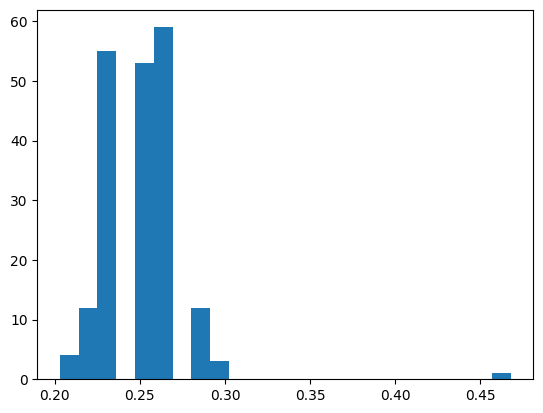

In [30]:
plt.hist(np.array(times[1:]) - np.array(times[:-1]), bins=24)